<a href="https://colab.research.google.com/github/jagan93550/NLP_projects/blob/main/nlp_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
data = {
    "Review": [
        "The food was delicious and served hot.",
        "Delivery was very late and food was cold.",
        "Excellent customer service and tasty meals.",
        "Packaging was damaged and food spilled.",
        "Loved the pasta and pizza. Great experience.",
        "The food quality was poor and overpriced.",
        "Fast delivery and fresh food.",
        "Customer support quickly resolved my issue.",
        "The burger was stale and not worth the price.",
        "Amazing dining experience and friendly staff.",
        "Food arrived on time and tasted great.",
        "The order was incorrect and disappointing.",
        "Affordable prices and excellent quality.",
        "Long waiting time and rude staff.",
        "Fresh ingredients and good presentation.",
        "The soup was cold and lacked flavor.",
        "Very clean restaurant and courteous employees.",
        "Overpriced menu with average food quality.",
        "Quick service and delicious desserts.",
        "Terrible delivery experience and poor packaging."
    ]
}

df = pd.DataFrame(data)

print("Restaurant Review Dataset")
print(df.head())

Restaurant Review Dataset
                                         Review
0        The food was delicious and served hot.
1     Delivery was very late and food was cold.
2   Excellent customer service and tasty meals.
3       Packaging was damaged and food spilled.
4  Loved the pasta and pizza. Great experience.


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()
    print("Lower Case:", text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)
    print("Special Characters Removed:", text)

    words = word_tokenize(text)
    print("Tokenization:", words)

    words = [word for word in words if word not in stop_words]
    print("Stopwords Removed:", words)

    cleaned_text = " ".join(words)

    return cleaned_text

In [5]:
df['cleaned_review'] = df['Review'].apply(clean_text)

print(df[['Review', 'cleaned_review']])

Lower Case: the food was delicious and served hot.
Special Characters Removed: the food was delicious and served hot
Tokenization: ['the', 'food', 'was', 'delicious', 'and', 'served', 'hot']
Stopwords Removed: ['food', 'delicious', 'served', 'hot']
Lower Case: delivery was very late and food was cold.
Special Characters Removed: delivery was very late and food was cold
Tokenization: ['delivery', 'was', 'very', 'late', 'and', 'food', 'was', 'cold']
Stopwords Removed: ['delivery', 'late', 'food', 'cold']
Lower Case: excellent customer service and tasty meals.
Special Characters Removed: excellent customer service and tasty meals
Tokenization: ['excellent', 'customer', 'service', 'and', 'tasty', 'meals']
Stopwords Removed: ['excellent', 'customer', 'service', 'tasty', 'meals']
Lower Case: packaging was damaged and food spilled.
Special Characters Removed: packaging was damaged and food spilled
Tokenization: ['packaging', 'was', 'damaged', 'and', 'food', 'spilled']
Stopwords Removed: ['pac

In [6]:
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):

    score = sia.polarity_scores(review)
    compound = score['compound']

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [7]:
df['sentiment'] = df['cleaned_review'].apply(analyze_sentiment)

print("\nSentiment Analysis Results")
print(df[['Review', 'sentiment']])


Sentiment Analysis Results
                                              Review sentiment
0             The food was delicious and served hot.  Positive
1          Delivery was very late and food was cold.   Neutral
2        Excellent customer service and tasty meals.  Positive
3            Packaging was damaged and food spilled.  Negative
4       Loved the pasta and pizza. Great experience.  Positive
5          The food quality was poor and overpriced.  Negative
6                      Fast delivery and fresh food.  Positive
7        Customer support quickly resolved my issue.  Positive
8      The burger was stale and not worth the price.  Positive
9      Amazing dining experience and friendly staff.  Positive
10            Food arrived on time and tasted great.  Positive
11        The order was incorrect and disappointing.  Negative
12          Affordable prices and excellent quality.  Positive
13                 Long waiting time and rude staff.  Negative
14          Fresh ingredien

In [8]:
all_words = " ".join(df['cleaned_review'])

word_list = all_words.split()

word_freq = Counter(word_list)

print("\nTop 10 Common Words")
print(word_freq.most_common(10))


Top 10 Common Words
[('food', 7), ('delivery', 3), ('experience', 3), ('quality', 3), ('delicious', 2), ('cold', 2), ('excellent', 2), ('customer', 2), ('service', 2), ('packaging', 2)]


In [9]:
negative_reviews = df[df['sentiment'] == 'Negative']

negative_words = " ".join(negative_reviews['cleaned_review'])

negative_word_list = negative_words.split()

complaint_freq = Counter(negative_word_list)

print("\nMost Common Service Issues")
print(complaint_freq.most_common(10))


Most Common Service Issues
[('packaging', 2), ('food', 2), ('poor', 2), ('damaged', 1), ('spilled', 1), ('quality', 1), ('overpriced', 1), ('order', 1), ('incorrect', 1), ('disappointing', 1)]


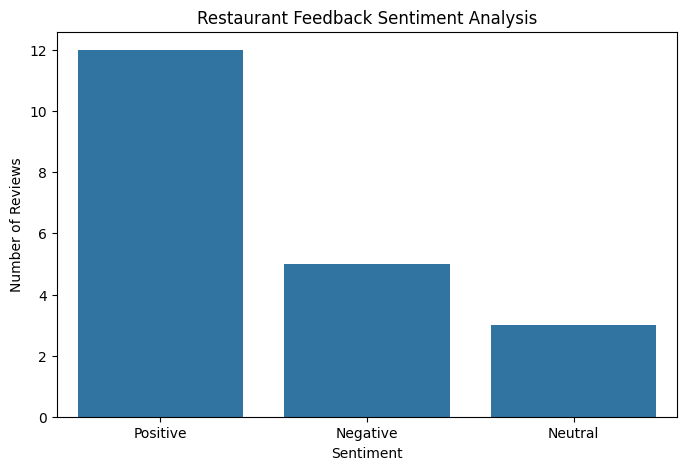

In [10]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Restaurant Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

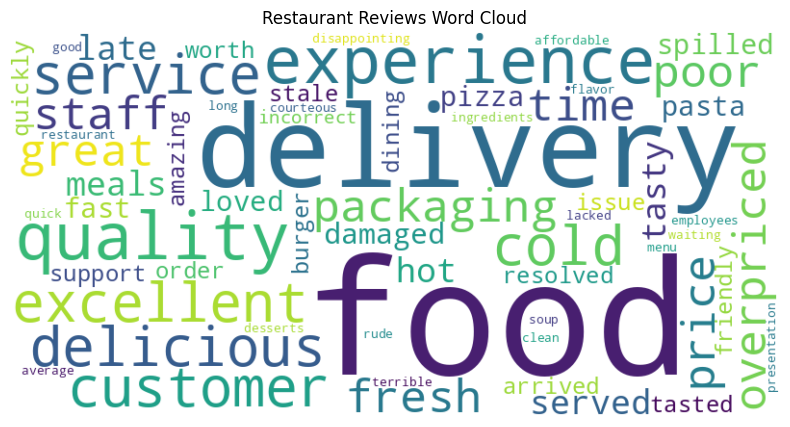

In [11]:
wordcloud_generator = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud_generator, interpolation='bilinear')

plt.axis('off')

plt.title("Restaurant Reviews Word Cloud")

plt.show()